# **Numeric Attributes Analysis**

In [70]:

from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("adult.csv")
df.head()

Saving adult.csv to adult (2).csv


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## **Choosing Numeric Attributes**

In [2]:
numeric_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
numeric_cols


['age',
 'fnlwgt',
 'education.num',
 'capital.gain',
 'capital.loss',
 'hours.per.week']

## **Five-number summary & descriptive stats**

In [3]:
summary_stats = df[numeric_cols].describe()
print("Five-number summary & descriptive stats:\n", summary_stats)

Five-number summary & descriptive stats:
                 age        fnlwgt  education.num  capital.gain  capital.loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours.per.week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


**Interpretation:**



*   **Age:** min = 17, Q1 = 28, median = 37, Q3 = 48, max = 90. Most individuals are between 28–48 years old.

*  **Hours-per-week:** min = 1, Q1 = 40, median = 40, Q3 = 45, max = 99. Most people work full-time (40 hrs), but there are extreme outliers.
*   **Education-num:** ranges from 1 to 16, with most values between 9–13 (high school to some college).


*   **fnlwgt:** very large spread due to census weighting.
List item





## **Mode for each numeric attribute**

In [5]:
mode_values = df[numeric_cols].mode().iloc[0]
print("Mode values:\n", mode_values)

Mode values:
 age                   36.0
fnlwgt            123011.0
education.num          9.0
capital.gain           0.0
capital.loss           0.0
hours.per.week        40.0
Name: 0, dtype: float64


**Interpretation:**

The most frequent values reflect common patterns in the dataset:


*   **Age:** 36 is the most frequent.

*   **Hours-per-week:** 40 is the most common, confirming that standard full-time work is typical.
*   **Education-num:** 9 (HS-grad) is most frequent.
Capital-gain / Capital-loss: both have a mode of 0, meaning the vast majority report no gains or losses.






## **Variance of numeric attributes**

In [6]:
variance = df[numeric_cols].var(numeric_only=True)
print("Variance:\n", variance)

Variance:
 age               1.860614e+02
fnlwgt            1.114080e+10
education.num     6.618890e+00
capital.gain      5.454254e+07
capital.loss      1.623769e+05
hours.per.week    1.524590e+02
dtype: float64


**Interpretation:**



*  **fnlwgt** has the highest variance, which makes sense since it’s a census sampling weight.

*   **Capital-gain / Capital-loss** also have high variance because of a few extreme values, even though most are 0.
*   **Age** and **hours-per-week** have moderate variance, showing real-world diversity in working patterns and ages.








## **Plots (Histogram, Boxplot, Scatter)**

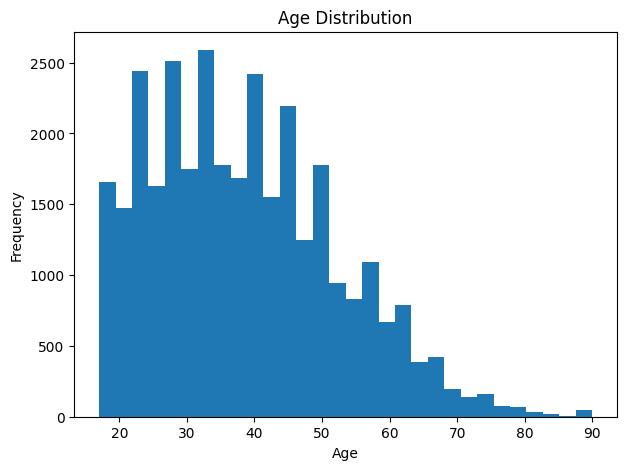

In [7]:
import matplotlib.pyplot as plt

# Histogram: Age
plt.figure(figsize=(7,5))
plt.hist(df["age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The distribution of age is right-skewed. Most individuals are between 20-50 years old, with relatively few older participants above 70.

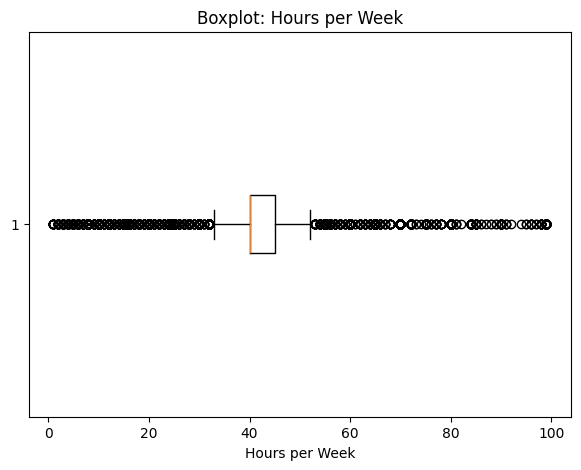

In [9]:
# Boxplot: Hours per Week
plt.figure(figsize=(7,5))
plt.boxplot(df["hours.per.week"].dropna(), vert=False)
plt.title("Boxplot: Hours per Week")
plt.xlabel("Hours per Week")
plt.show()

The majority of individuals work around 40 hours per week. However, outliers are present — some report working very low hours (part-time) and others extremely high (up to 99).

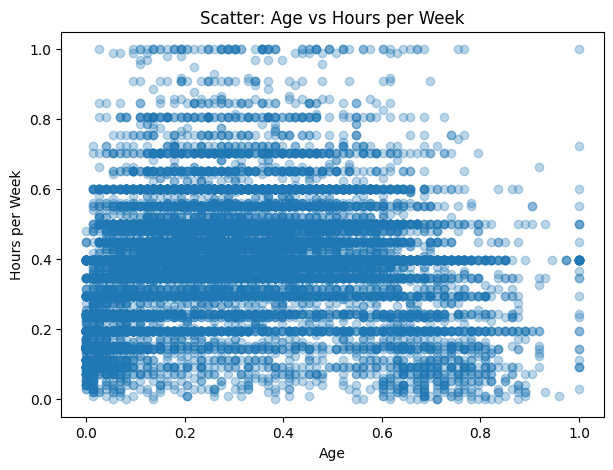

In [64]:
# Scatter: Age vs Hours per Week
plt.figure(figsize=(7,5))
plt.scatter(df["age"], df["hours.per.week"], alpha=0.3)
plt.title("Scatter: Age vs Hours per Week")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.show()




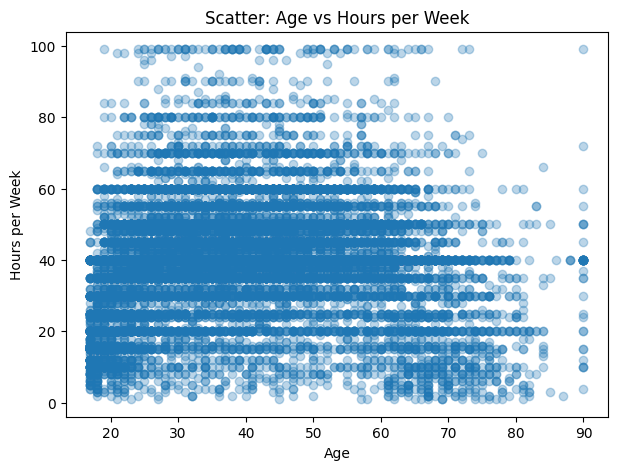

In [ ]:
# Scatter: Age vs Hours per Week
plt.figure(figsize=(7,5))
plt.scatter(df["age"], df["hours.per.week"], alpha=0.3)
plt.title("Scatter: Age vs Hours per Week")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.show()

There is no strong correlation between age and hours-per-week. Most individuals cluster around 20–60 years old working 35–45 hours. Outliers appear as unusual points (e.g., very old age with extreme hours).

### How this analysis indicates the need for preprocessing
From the numeric analysis, we observed that:
- `capital-gain` and `capital-loss` are highly skewed with many zero values and extreme outliers.
- Several attributes (e.g., `fnlwgt`, `hours-per-week`) have large variance, showing inconsistent scales that will need normalization.
- There are also some missing or invalid entries that must be handled.

These findings indicate that our dataset requires **outlier treatment**, **scaling**, and **handling of missing values** during preprocessing to improve model performance.


# **Categorical Attributes Analysis**


## **Choosing Categorical Attributes**


In [74]:
categorical_cols = ["workclass", "education", "marital.status",
                    "occupation", "relationship", "race", "sex",
                    "native.country", "income"]
categorical_cols


['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country',
 'income']

## **Frequency and Mode for Each Categorical Attribute**


In [ ]:
# Frequency counts for categorical attributes
categorical_cols = ["workclass", "education", "marital.status",
                    "occupation", "relationship", "race", "sex",
                    "native.country", "income"]

for col in categorical_cols:
    print(f"\nValue counts for {col}:\n")
    print(df[col].value_counts())



Value counts for workclass:

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

Value counts for education:

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

Value counts for marital.status:

marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dt

**Interpretation: Frequency Counts**

The frequency counts show that some categories dominate the dataset while others are rare.







*   For example, in workclass, the majority are in Private.

*   In education, categories such as HS-grad and Some-college occur most frequently, while Preschool or Doctorate are rare.
*   In sex, males appear more often than females.


*  For native-country, most individuals are from the United States, while other countries occur very few times.


This confirms that the dataset has imbalances across categorical attributes, which must be considered in preprocessing.

## **Visualization of Categorical Attributes**


### **Workclass Distribution**


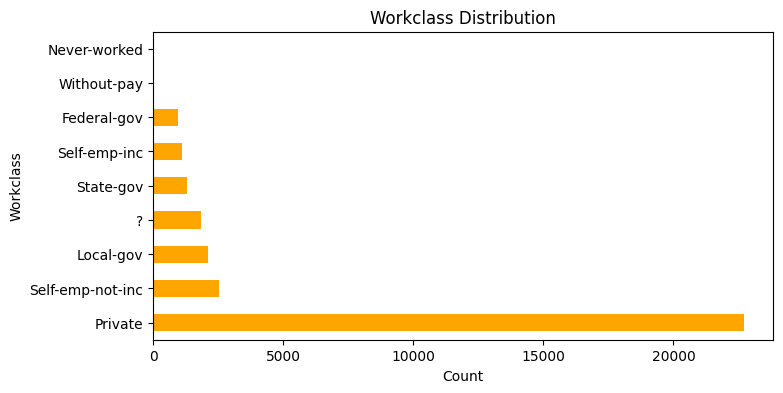

In [ ]:
# Bar plot: Workclass
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
df["workclass"].value_counts().plot(kind="barh", color="orange")
plt.title("Workclass Distribution")
plt.xlabel("Count")
plt.ylabel("Workclass")
plt.show()



**Interpretation: Workclass Distribution**

Most individuals work in the Private sector. Other categories like Self-emp-not-inc and Local-gov are less common, while Never-worked and Without-pay are extremely rare.

### **Education Distribution**


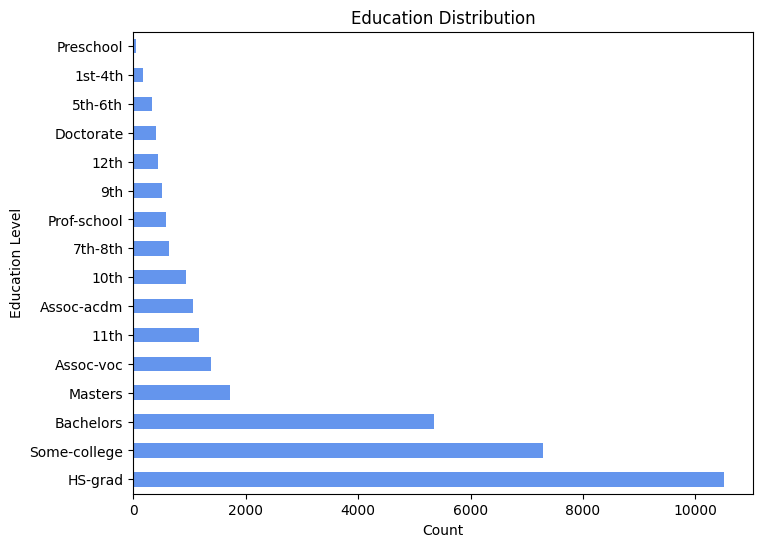

In [ ]:
# Bar plot: Education
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
df["education"].value_counts().plot(kind="barh", color="cornflowerblue")
plt.title("Education Distribution")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.show()



**Interpretation: Education Distribution**

The plot shows that most individuals fall into the categories HS-grad, Some-college, and Bachelors. Rare categories like Preschool and Doctorate appear very few times, indicating imbalance in education levels.

### **Sex Distribution**


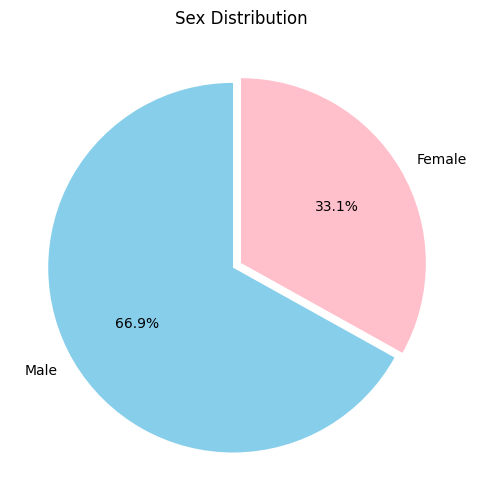

In [ ]:
# Pie chart: Sex
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
df["sex"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue", "pink"],
    startangle=90,
    explode=(0.05, 0)
)
plt.title("Sex Distribution")
plt.ylabel("")
plt.show()


**Interpretation: Sex Distribution**

The dataset contains more males than females. This imbalance may bias models toward the majority gender.

### **Race Distribution**


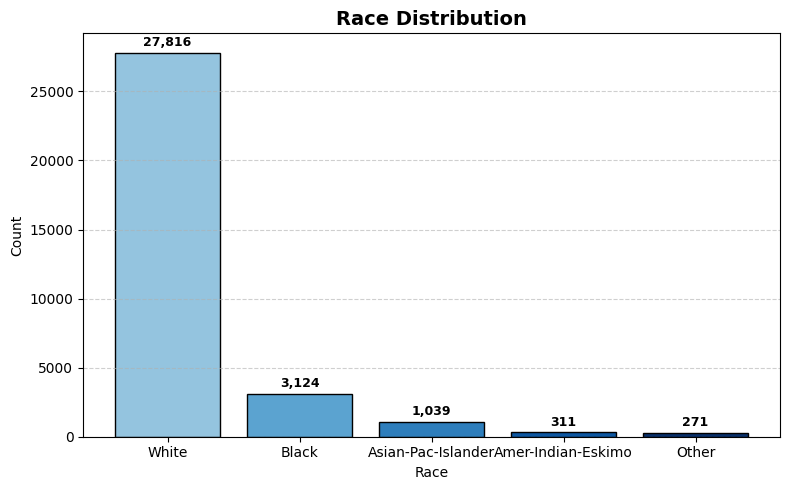

In [ ]:
# Column chart: Race
import matplotlib.pyplot as plt
import numpy as np

race_counts = df["race"].value_counts()
colors = plt.cm.Blues(np.linspace(0.4, 1, len(race_counts)))

plt.figure(figsize=(8,5))
bars = plt.bar(race_counts.index, race_counts.values, color=colors, edgecolor='black')

plt.title("Race Distribution", fontsize=14, weight="bold")
plt.xlabel("Race")
plt.ylabel("Count")


for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f'{bar.get_height():,}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


**Interpretation: Race Distribution**

The majority of individuals are White, followed by Black. Other races such as Asian-Pac-Islander and Amer-Indian-Eskimo appear less frequently, showing race imbalance.

### **Income vs Hours per Week**


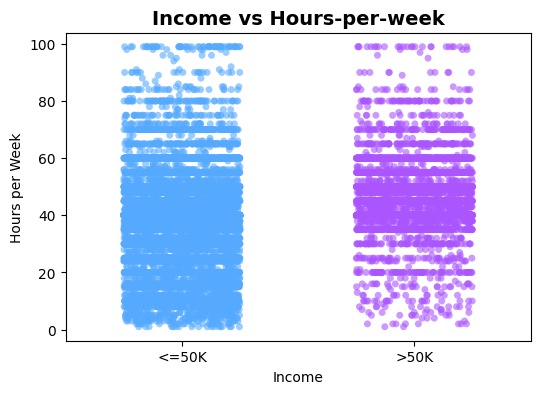

In [ ]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.stripplot(
    x="income",
    y="hours.per.week",
    data=df,
    hue="income",
    palette="cool",
    dodge=False,
    jitter=0.25,
    alpha=0.6,
    legend=False
)
plt.title("Income vs Hours-per-week", fontsize=14, weight="bold")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.show()


**Interpretation: Income Distribution**

Most individuals have income <=50K, while fewer individuals earn >50K. This imbalance in the target variable may require preprocessing such as resampling.

### How this analysis indicates the need for preprocessing
The categorical analysis revealed:
- Some columns (e.g., `workclass`, `occupation`, `native.country`) contain “?” or blank entries, meaning **missing data** must be cleaned.
- Several categorical attributes have many unique values (high cardinality), so **encoding** will be needed.
- Class imbalance was seen in `income` (most samples are <=50K), meaning we may need **balancing techniques** later.

These observations confirm that **data cleaning, encoding, and balancing** are essential preprocessing steps.


### Why preprocessing is necessary
Based on the statistical summaries and visualizations from Phase 2 – Data Analysis, the dataset contains:
- Missing values and inconsistent labels.
- Skewed numeric distributions and outliers.
- Mixed data types requiring encoding.

Therefore, preprocessing is required to make the dataset ready for accurate and reliable modeling.


# **Data Preprocessing**

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler


**Data Cleaning** Missing values in this step missing values were replaced using mode imputation, Duplicates were removed .Outliers were handled using the IQR method.

In [ ]:
df = df.replace("?", pd.NA)


In [ ]:
cols_with_missing = ["workclass", "occupation", "native.country"]

for col in cols_with_missing:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)



The colmuns woekclass , occupation and native-country contanied missing values, these were replaced by most frequent(mode) values in each column.

## **Label Encoding - Gender**

In [40]:
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])


The gender column was converted to numeric from using Label Encoding so algorthims can interpet it correctly(Male=1 , Female=0).

## **One-Hot Encoding - Multi-category coulmns**

In [42]:
df = pd.get_dummies(
    df,
    columns=["workclass", "education", "marital.status"],
    drop_first=True
)


Multi-class categorial feauters were transformed using One-Hot Encoding to prevent any false ordering between categories to creat binary indicator columns.

## **Normalization - Min-Max Scaling**

In [44]:
numeric_cols = ["age", "hours.per.week", "capital.gain", "capital.loss"]

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


Numerical columns were scaled to the range [0, 1] using Min-Max Normalization This ensures that all numeric features contribute equally and avoids dominance of large-scale values.

## **Final Summary and Justification**

In [45]:
df.to_csv("Preprocessed_step3.csv", index=False)

In [46]:
print("Perview of the dataset after preprocessing : ")
print(df.head())
print("\nDataset information after preprocessing : ")
print(df.info())

Perview of the dataset after preprocessing : 
        age  fnlwgt  education.num         occupation   relationship   race  \
0  1.000000   77053              9               <NA>  Not-in-family  White   
1  0.890411  132870              9    Exec-managerial  Not-in-family  White   
2  0.671233  186061             10               <NA>      Unmarried  Black   
3  0.506849  140359              4  Machine-op-inspct      Unmarried  White   
4  0.328767  264663             10     Prof-specialty      Own-child  White   

   sex  capital.gain  capital.loss  hours.per.week  ... education_Masters  \
0    0           0.0      1.000000        0.397959  ...             False   
1    0           0.0      1.000000        0.173469  ...             False   
2    0           0.0      1.000000        0.397959  ...             False   
3    0           0.0      0.895317        0.397959  ...             False   
4    0           0.0      0.895317        0.397959  ...             False   

  education_Pres

After preprocessing, missing data were imputed, categorical features were encoded, and numerical attributes were normalized. These steps improved data consistency and comparability, preparing the dataset for accurate modeling.

## **Feature Selection**

In [48]:
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

X = df.drop("income", axis=1)
y = df["income"]

X = pd.get_dummies(X, drop_first=True)

selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(X, y)

selected_columns = X.columns[selector.get_support()]
print("Top 10 selected features:")
print(selected_columns)


Top 10 selected features:
Index(['fnlwgt', 'education.num', 'education_Bachelors', 'education_Masters',
       'marital.status_Married-civ-spouse', 'marital.status_Never-married',
       'occupation_Exec-managerial', 'occupation_Prof-specialty',
       'relationship_Not-in-family', 'relationship_Own-child'],
      dtype='object')


The **Chi-Square (χ²)** test checks how strongly each feature is related to the income column.
Higher scores mean that feature is more important for prediction.
This helps reduce irrelevant data and improves model performance.


## **Discretization**

In [50]:
from sklearn.preprocessing import KBinsDiscretizer

discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')

df["age_binned"] = discretizer.fit_transform(df[["age"]])
df["hours_binned"] = discretizer.fit_transform(df[["hours.per.week"]])

# Show a sample
df[["age", "age_binned", "hours.per.week", "hours_binned"]].head(10)


,age,age_binned,hours.per.week,hours_binned
0,1.000000,3.0,0.397959,1.0
1,0.890411,3.0,0.173469,0.0
2,0.671233,2.0,0.397959,1.0
3,0.506849,2.0,0.397959,1.0
4,0.328767,1.0,0.397959,1.0
5,0.232877,0.0,0.448980,1.0
6,0.287671,1.0,0.397959,1.0
7,0.780822,3.0,0.193878,0.0
8,0.698630,2.0,0.397959,1.0
9,0.328767,1.0,0.602041,2.0


Discretization divides continuous numbers into groups.
For example, age values are split into 4 ranges:
0 = young, 1 = adult, 2 = middle-age, 3 = senior.
This makes data easier to interpret and reduces the effect of extreme values.

## **Save preprocessed dataset**

In [53]:
df.to_csv("Preprocessed_dataset.csv", index=False)
print("Preprocessed dataset saved successfully!")


Preprocessed dataset saved successfully!


We save our new, clean version of the dataset as '*Preprocessed_dataset.csv*'
so we can use it in Phase 3 for classification and clustering.

This shows a small preview of the data before and after our transformations.
You'll notice fewer irrelevant columns and cleaner numeric values.

# **Snapshots: Raw vs Preprocessed**

In [66]:
print("Raw dataset sample:")
display(df.head(3))

print("Preprocessed dataset sample (selected columns):")
display(df[['age', 'age_binned', 'hours.per.week', 'hours_binned', 'income']].head(3))


Raw dataset sample:


,age,fnlwgt,education.num,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,...,education_Prof-school,education_Some-college,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed,age_binned,hours_binned
0,1.000000,77053,9,<NA>,Not-in-family,White,0,0.0,1.0,0.397959,...,False,False,False,False,False,False,False,True,3.0,1.0
1,0.890411,132870,9,Exec-managerial,Not-in-family,White,0,0.0,1.0,0.173469,...,False,False,False,False,False,False,False,True,3.0,0.0
2,0.671233,186061,10,<NA>,Unmarried,Black,0,0.0,1.0,0.397959,...,False,True,False,False,False,False,False,True,2.0,1.0


Preprocessed dataset sample (selected columns):


,age,age_binned,hours.per.week,hours_binned,income
0,1.000000,3.0,0.397959,1.0,<=50K
1,0.890411,3.0,0.173469,0.0,<=50K
2,0.671233,2.0,0.397959,1.0,<=50K
